<a href="https://colab.research.google.com/github/waelydz/ASD-Sense/blob/main/Model_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Environment Setup and Data Acquisition

In [1]:
!pip install kagglehub scikit-learn -q

import os
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Download dataset
dataset_path = kagglehub.dataset_download('imranliaqat32/autism-spectrum-disorder-in-childrenhandgestures')

# Locate target directory
DATA_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if 'ASD' in dirs and 'Non-ASD' in dirs:
        DATA_DIR = root
        break

if not DATA_DIR:
    raise FileNotFoundError("Target class directories 'ASD' and 'Non-ASD' not found.")

Using Colab cache for faster access to the 'autism-spectrum-disorder-in-childrenhandgestures' dataset.


Data Preprocessing and Class Weight Computation

In [2]:
data = []
for category_folder in ['ASD', 'Non-ASD']:
    category_path = os.path.join(DATA_DIR, category_folder)
    label = 'no' if category_folder == 'Non-ASD' else 'yes'
    # Use os.walk to drill down into all nested subdirectories
    for root_dir, _, files in os.walk(category_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                data.append({'filepath': os.path.join(root_dir, file), 'label': label})

df = pd.DataFrame(data)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Compute class weights for imbalanced data
weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weights_dict = {0: weights[0], 1: weights[1]}

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 909 validated image filenames belonging to 2 classes.
Found 228 validated image filenames belonging to 2 classes.


Model Architecture and Feature Alignment (Frozen Backbone)

In [3]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(224, 224, 3)
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    class_weight=class_weights_dict
)


Epoch 1/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 122s 4s/step - accuracy: 0.7679 - loss: 0.5032 - val_accuracy: 0.4956 - val_loss: 1.4879
Epoch 2/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.8086 - loss: 0.4311 - val_accuracy: 0.4956 - val_loss: 1.7303
Epoch 3/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8141 - loss: 0.4101 - val_accuracy: 0.4956 - val_loss: 1.5367
Epoch 4/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.7998 - loss: 0.4166 - val_accuracy: 0.4956 - val_loss: 1.3713
Epoch 5/5
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8207 - loss: 0.3782 - val_accuracy: 0.4956 - val_loss: 1.3199


Fine-Tuning and Evaluation

In [4]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    class_weight=class_weights_dict
)

final_val_acc = fine_tune_history.history['val_accuracy'][-1] * 100
print(f"ResNet50 Final Validation Accuracy: {final_val_acc:.2f}%")

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.7756 - loss: 0.5279 - val_accuracy: 0.4956 - val_loss: 2.0078
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.7998 - loss: 0.4460 - val_accuracy: 0.4956 - val_loss: 3.0856
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 95s 3s/step - accuracy: 0.8394 - loss: 0.3937 - val_accuracy: 0.4956 - val_loss: 3.6125
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.8119 - loss: 0.4033 - val_accuracy: 0.4956 - val_loss: 3.7234
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.8427 - loss: 0.3661 - val_accuracy: 0.4956 - val_loss: 3.4106
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8515 - loss: 0.3461 - val_accuracy: 0.4956 - val_loss: 3.0698
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 99s 3s/step - accuracy: 0.8218 - loss: 0.3952 - val_accuracy: 0.4956 - val_loss: 2.8499
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.8449 - loss: 0.3776 - val_accuracy: 0.4956 - val_l

Plotting

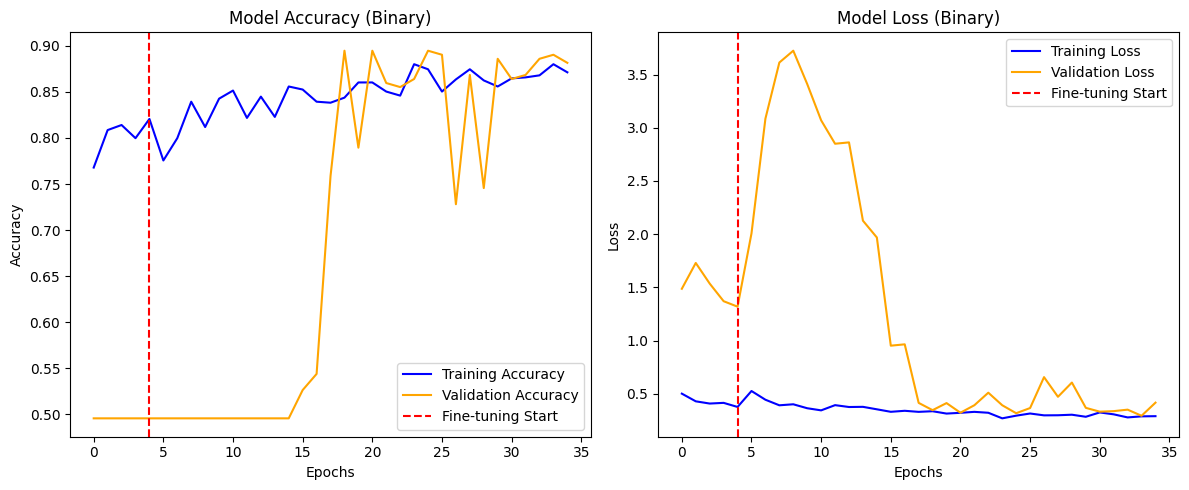

In [5]:
import matplotlib.pyplot as plt

def plot_results(hist1, hist2):
    acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', color='blue')
    plt.plot(val_acc, label='Validation Accuracy', color='orange')
    plt.axvline(x=4, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('Model Accuracy (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='orange')
    plt.axvline(x=4, color='r', linestyle='--', label='Fine-tuning Start')
    plt.title('Model Loss (Binary)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()

    # Save the figure in high resolution
    filename = 'binary_training_results.png'
    plt.savefig(filename, dpi=300)
    plt.show()

plot_results(history, fine_tune_history)